# 96-Well Plate: Exploratory Data Analysis (Pilot Study)

This notebook looks at the tidy 96-well dataset visually and descriptively, before any modelling. The goal here is understanding the data's shape, quality, and rough structure, not drawing conclusions about wine discrimination.

## Imports and data load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../../data/processed/master_df_96.csv")

## Initial inspection

Basic questions before anything else: how many rows, what columns exist,
which column is the wine label, and whether the dtypes look right.

In [3]:
df.head()

,Wavelength,Well,Absorbance,Plate,Peptide,Sensor,Wine,Replicate
0,350,A1,0.2467,W1_2_P1_7,1.0,Cu-PCV-P1,HEPES,NaN
1,352,A1,0.2454,W1_2_P1_7,1.0,Cu-PCV-P1,HEPES,NaN
2,354,A1,0.2444,W1_2_P1_7,1.0,Cu-PCV-P1,HEPES,NaN
3,356,A1,0.2430,W1_2_P1_7,1.0,Cu-PCV-P1,HEPES,NaN
4,358,A1,0.2414,W1_2_P1_7,1.0,Cu-PCV-P1,HEPES,NaN


In [4]:
df.tail()

,Wavelength,Well,Absorbance,Plate,Peptide,Sensor,Wine,Replicate
125812,742,H12,0.0403,W5_6_P8_14,NaN,Wine control,HEPES,NaN
125813,744,H12,0.0407,W5_6_P8_14,NaN,Wine control,HEPES,NaN
125814,746,H12,0.0407,W5_6_P8_14,NaN,Wine control,HEPES,NaN
125815,748,H12,0.0406,W5_6_P8_14,NaN,Wine control,HEPES,NaN
125816,750,H12,0.0411,W5_6_P8_14,NaN,Wine control,HEPES,NaN


In [5]:
df.shape

(125817, 8)

In [6]:
df.columns

Index(['Wavelength', 'Well', 'Absorbance', 'Plate', 'Peptide', 'Sensor',
       'Wine', 'Replicate'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125817 entries, 0 to 125816
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Wavelength  125817 non-null  int64  
 1   Well        125817 non-null  object 
 2   Absorbance  125817 non-null  float64
 3   Plate       125817 non-null  object 
 4   Peptide     110448 non-null  float64
 5   Sensor      125817 non-null  object 
 6   Wine        125817 non-null  object 
 7   Replicate   105400 non-null  float64
dtypes: float64(3), int64(1), object(4)
memory usage: 7.7+ MB


## Data quality checks

Missing values, duplicate rows, and summary statistics. Standard checks before trusting any downstream analysis.

In [8]:
df.isnull().sum().sort_values(ascending = False)

Replicate     20417
Peptide       15369
Wavelength        0
Well              0
Absorbance        0
Plate             0
Sensor            0
Wine              0
dtype: int64

Replicate is null exactly where Wine is "HEPES" (the buffer-only control wells), which is expected. Controls don't have a replicate number in the same sense a wine sample does, so this isn't missing data to be concerned about.

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.describe()

,Wavelength,Absorbance,Peptide,Replicate
count,125817.000000,125817.000000,110448.000000,105400.000000
mean,562.843256,0.119792,7.458007,2.987846
std,129.860135,0.103303,4.012102,1.414252
min,300.000000,0.036700,1.000000,1.000000
25%,452.000000,0.048400,4.000000,2.000000
50%,562.000000,0.066300,7.000000,3.000000
75%,674.000000,0.157400,11.000000,4.000000
max,800.000000,0.647200,14.000000,5.000000


Peptide is a categorical identifier (which peptide occupies a given plate row), not a meaningful numeric quantity. Summary statistics and correlations involving Peptide as if it were ordinal/continuous should be disregarded as they're an artifact of the column's storage type, not a real relationship.

## Class distribution

In [11]:
df["Wine"].value_counts()

Wine
HEPES    20417
W1       18080
W2       18080
W5       18080
W6       17402
W3       17080
W4       16678
Name: count, dtype: int64

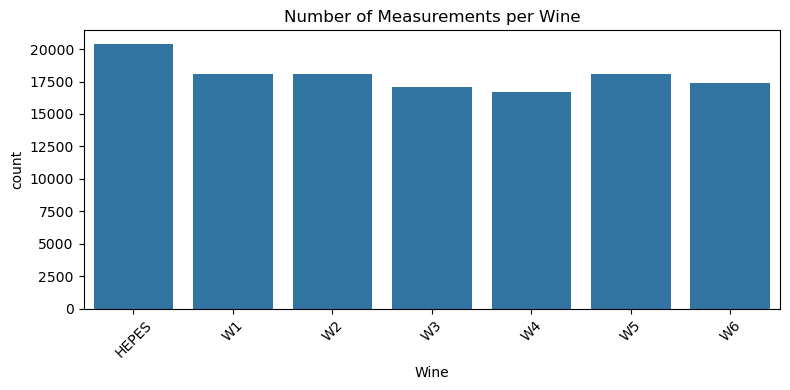

In [12]:
plt.figure(figsize = (8, 4))
sns.countplot(data = df, x = "Wine")
plt.xticks(rotation = 45)
plt.title("Number of Measurements per Wine")
plt.tight_layout()
plt.show()

## Distribution of absorbance values

Checking whether absorbance is skewed, multi-modal, or has unusually
extreme values, before relying on it in later modelling.

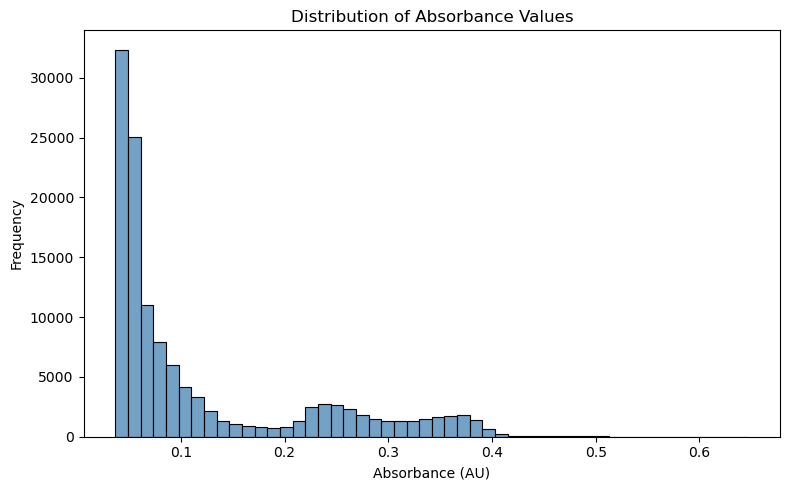

In [13]:
plt.figure(figsize = (8, 5))

sns.histplot(
    data = df,
    x = "Absorbance",
    bins = 50,
    color = "steelblue"
)

plt.title("Distribution of Absorbance Values")
plt.xlabel("Absorbance (AU)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

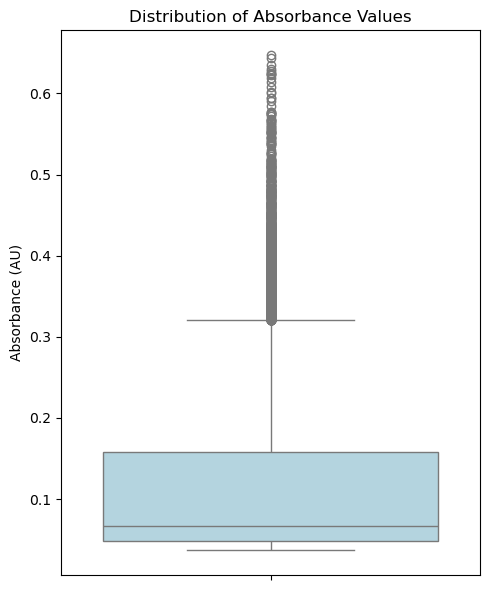

In [14]:
plt.figure(figsize = (5, 6))

sns.boxplot(
    y = df["Absorbance"],
    color = "lightblue"
)

plt.title("Distribution of Absorbance Values")
plt.ylabel("Absorbance (AU)")

plt.tight_layout()
plt.show()

## Correlation matrix

Any correlation involving Peptide reflects the arbitrary numbering of plate rows, not a real chemical relationship. Wavelength vs. Absorbance is the only pair here with an interpretable numeric relationship.

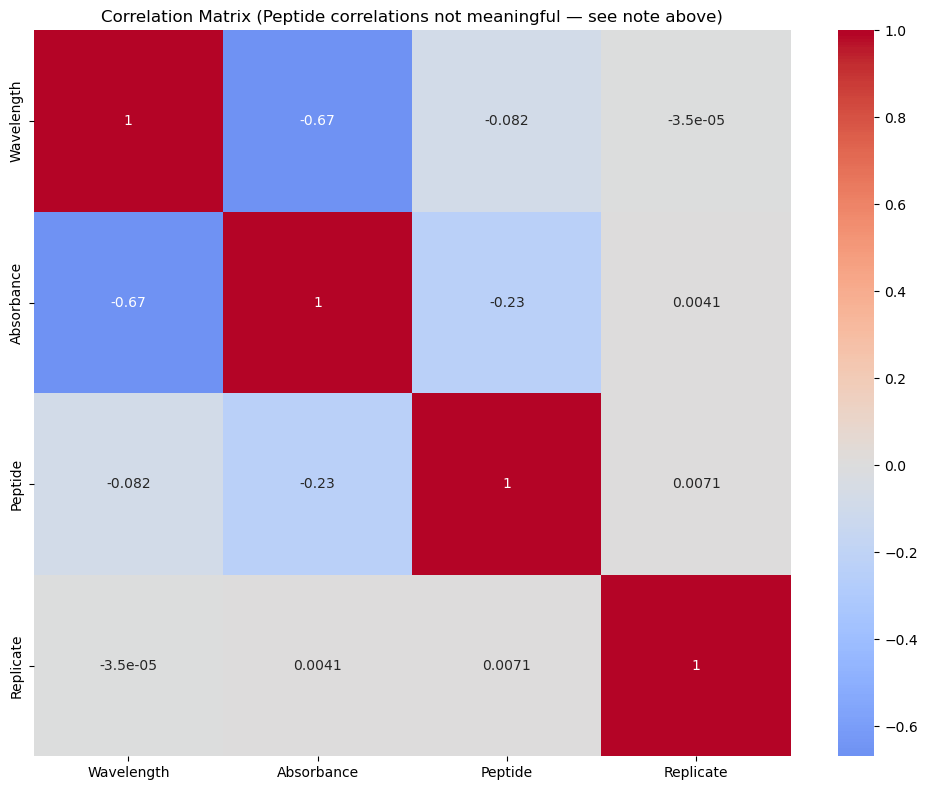

In [15]:
corr = df.corr(numeric_only = True)

plt.figure(figsize = (10, 8))
sns.heatmap(corr, cmap = "coolwarm", center = 0, annot = True)
plt.title("Correlation Matrix (Peptide correlations not meaningful — see note above)")
plt.tight_layout()
plt.show()

## Spectral overview

Mean absorbance spectrum for each wine and each peptide, and the equivalent view as heatmaps. A first visual at whether wines or peptides produce visibly distinct patterns.

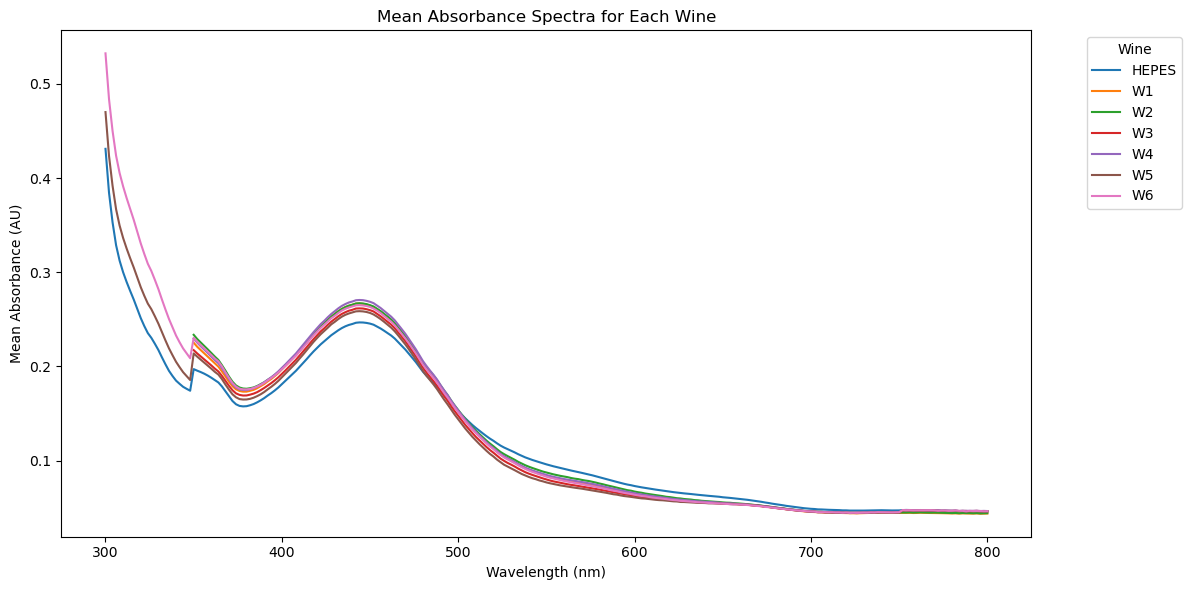

In [16]:
plt.figure(figsize = (12, 6))

sns.lineplot(
    data = df,
    x = "Wavelength",
    y = "Absorbance",
    hue = "Wine",
    estimator = "mean",
    errorbar = None
)

plt.title("Mean Absorbance Spectra for Each Wine")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Mean Absorbance (AU)")
plt.legend(title = "Wine", bbox_to_anchor = (1.05, 1), loc = "upper left")
plt.tight_layout()
plt.show()

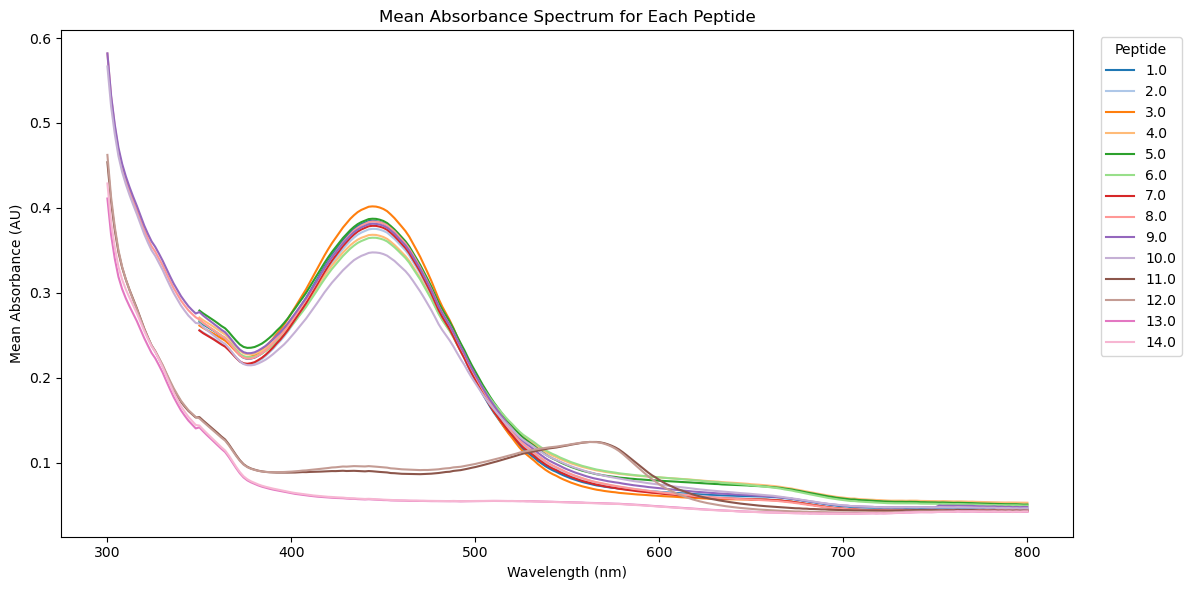

In [17]:
plt.figure(figsize = (12, 6))

sns.lineplot(
    data = df,
    x = "Wavelength",
    y = "Absorbance",
    hue = "Peptide",
    estimator = "mean",
    errorbar = None,
    palette = "tab20"
)

plt.title("Mean Absorbance Spectrum for Each Peptide")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Mean Absorbance (AU)")
plt.legend(title = "Peptide", bbox_to_anchor = (1.02, 1), loc = "upper left")
plt.tight_layout()
plt.show()

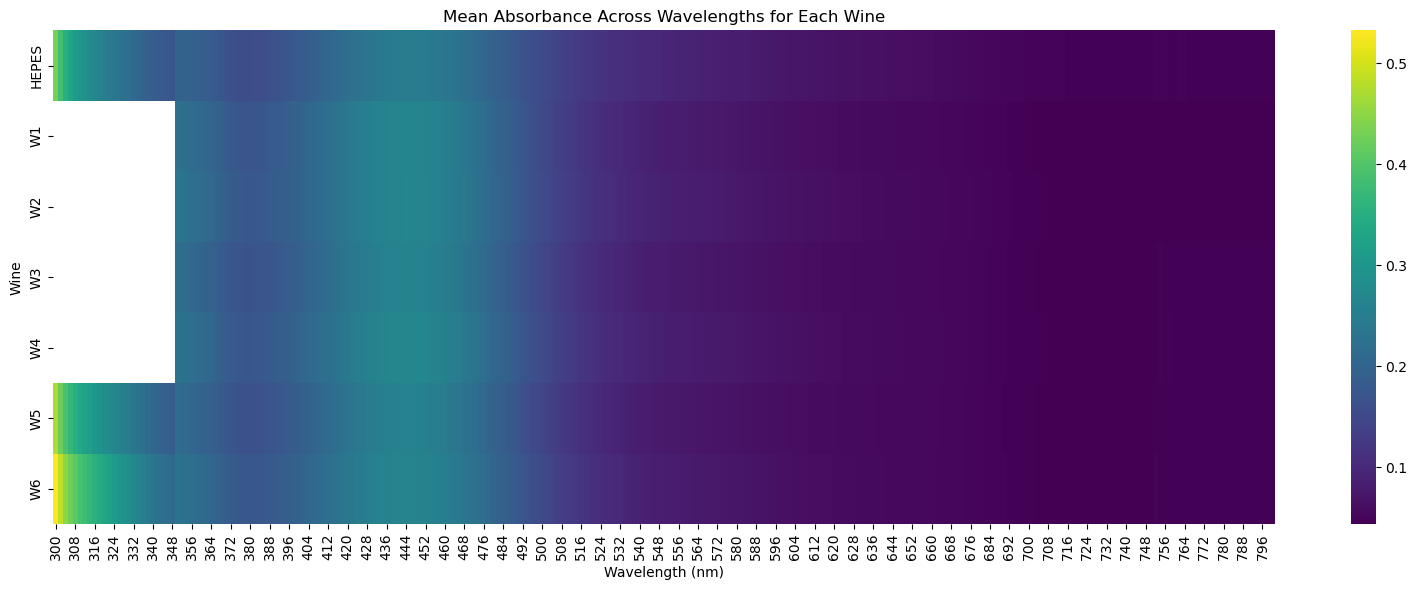

In [18]:
wine_heatmap = df.pivot_table(
    values = "Absorbance",
    index = "Wine",
    columns = "Wavelength",
    aggfunc = "mean"
)

plt.figure(figsize = (16, 6))
sns.heatmap(wine_heatmap, cmap = "viridis")
plt.title("Mean Absorbance Across Wavelengths for Each Wine")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Wine")
plt.tight_layout()
plt.show()

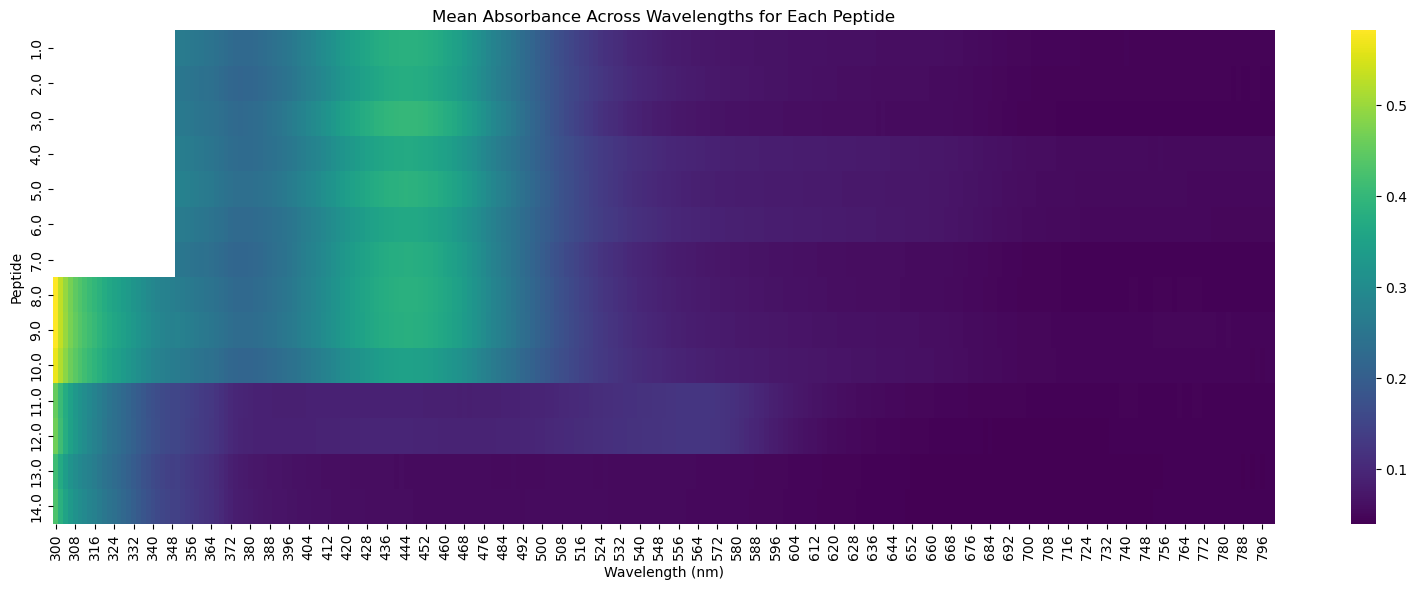

In [19]:
peptide_heatmap = df.pivot_table(
    values = "Absorbance",
    index = "Peptide",
    columns = "Wavelength",
    aggfunc = "mean"
)

plt.figure(figsize = (16, 6))
sns.heatmap(peptide_heatmap, cmap = "viridis")
plt.title("Mean Absorbance Across Wavelengths for Each Peptide")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Peptide")
plt.tight_layout()
plt.show()

## Replicate consistency

Checking that replicates of the same wine produce similar spectra, evidence of experimental reproducibility. All six wines are plotted in one grid rather than as six separate cells, since the plotting logic is identical for each and a grid makes it easier to compare consistency across wines.

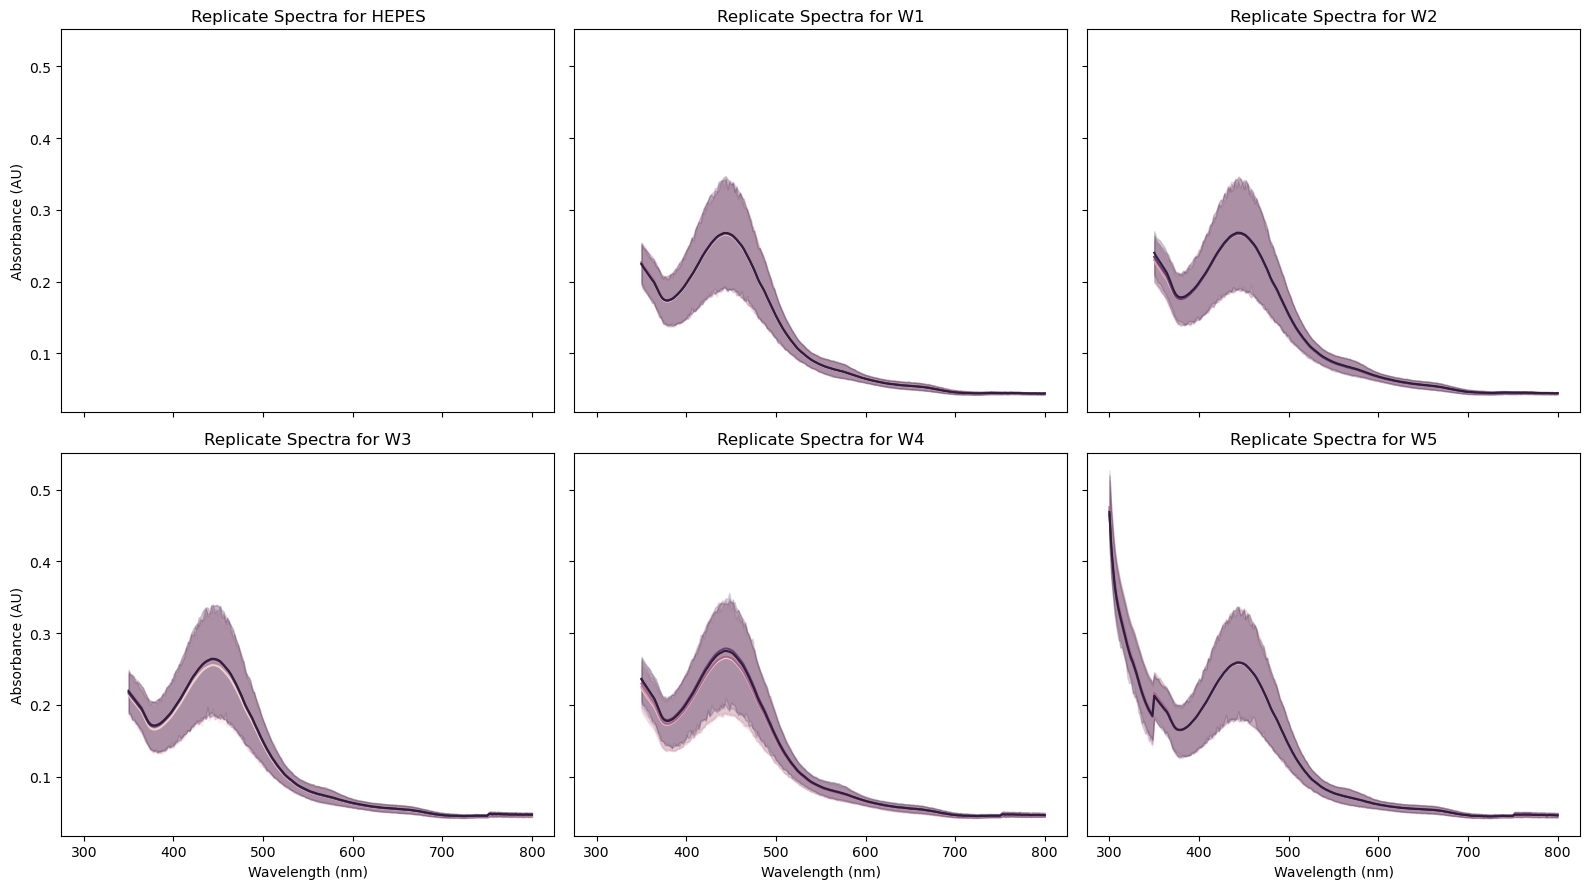

In [20]:
wine_list = sorted(df["Wine"].unique())

fig, axes = plt.subplots(2, 3, figsize = (16, 9), sharex = True, sharey = True)

for ax, wine_name in zip(axes.flat, wine_list):
    sns.lineplot(
        data = df[df["Wine"] == wine_name],
        x = "Wavelength",
        y = "Absorbance",
        hue = "Replicate",
        estimator = "mean",
        ax = ax,
        legend = (ax is axes.flat[0])
    )
    ax.set_title(f"Replicate Spectra for {wine_name}")
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("Absorbance (AU)")

plt.tight_layout()
plt.show()

## Per-peptide spectra by wine

The key exploratory figure for this notebook: each peptide's mean spectrum, split out by wine, to see peptide-by-peptide whether wines produce visibly distinct responses.

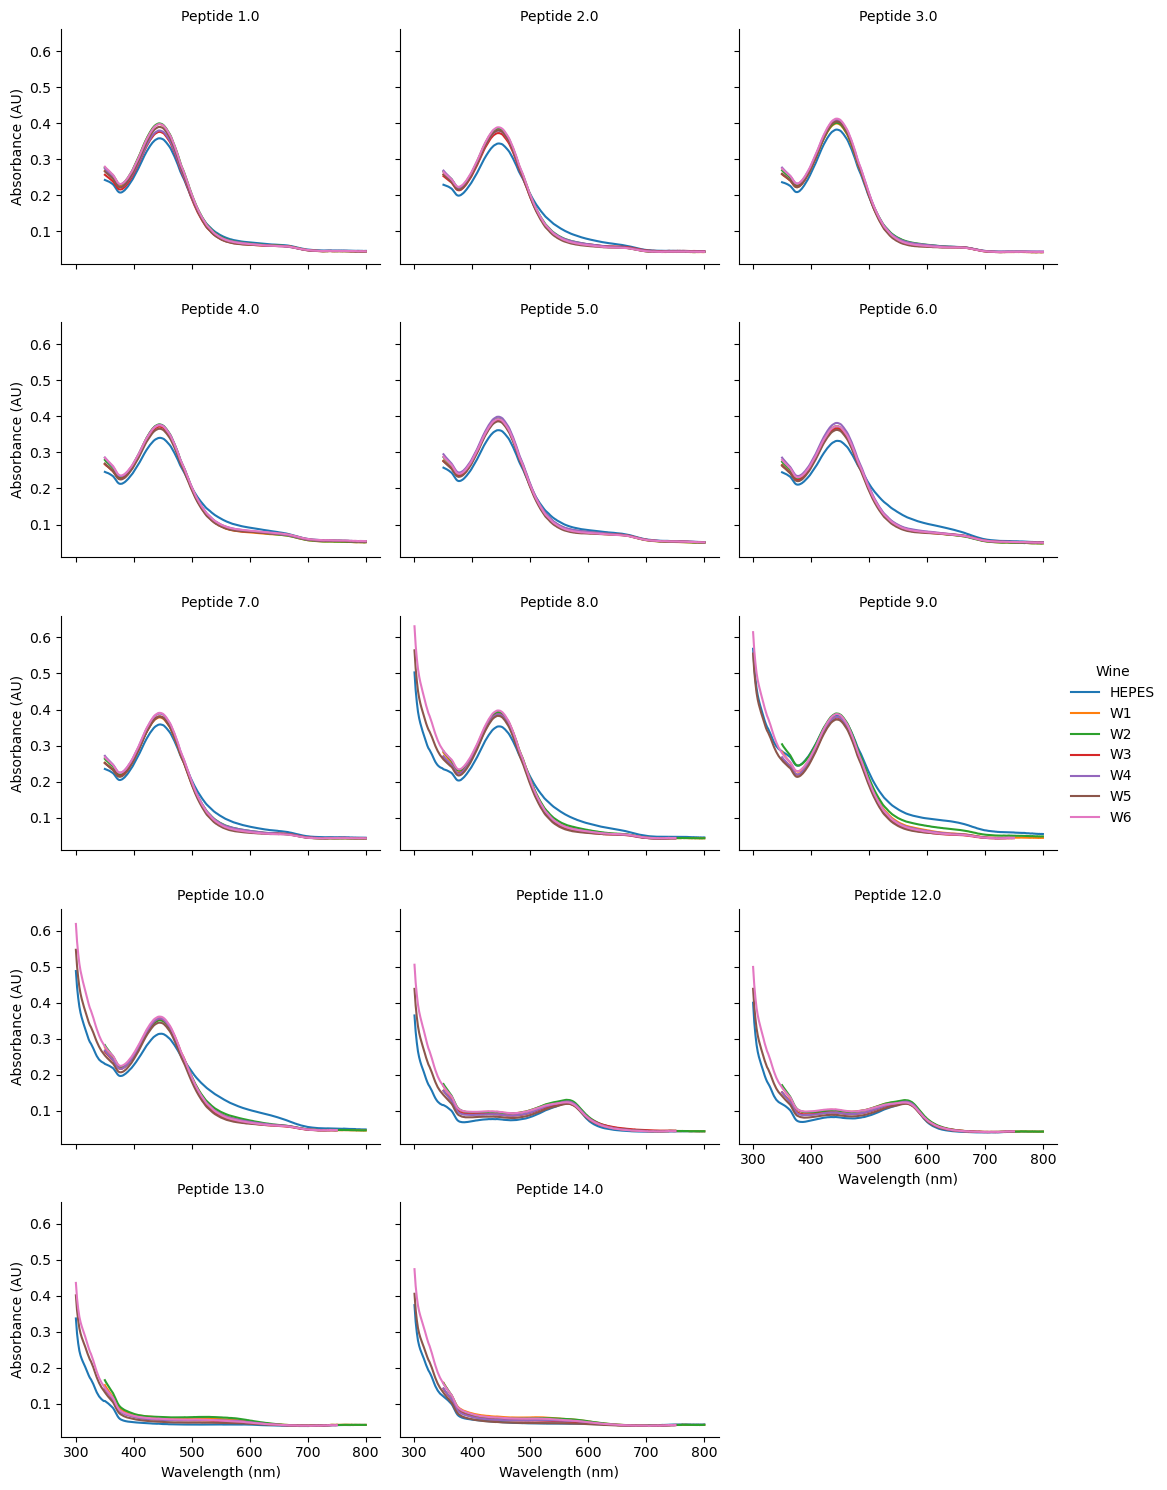

In [21]:
g = sns.relplot(
    data = df,
    x = "Wavelength",
    y = "Absorbance",
    hue = "Wine",
    col = "Peptide",
    kind = "line",
    estimator = "mean",
    errorbar = None,
    col_wrap = 3,
    height = 3,
    aspect = 1.2
)

g.set_axis_labels("Wavelength (nm)", "Absorbance (AU)")
g.set_titles("Peptide {col_name}")

plt.show()

Some peptide panels show wines visibly separating within the 550-650nm band and others show wines sitting on top of each other throughout. This is a useful first visual answer to "which peptides discriminate wines," but it rests on an assumed band rather than a systematic scan. A per-wavelength F-statistic scan has not yet been run for this pilot dataset.